# Customer Churn Prediction
A Deep Learning mini project which performs binary classification between the customers who will leave the credit card service of a bank or not.

## Stack:
* Python
* Keras
* Kaggle

### Dataset: [Credit Card Customer Churn Prediction](https://www.kaggle.com/datasets/rjmanoj/credit-card-customer-churn-prediction)

In [1]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub

/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv')

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

In [5]:
df = pd.get_dummies(df, columns=['Gender', 'Geography'], drop_first=True, dtype=int)

In [6]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Gender_Male,Geography_Germany,Geography_Spain
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,0,1
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,0,1


In [7]:
X = df.drop(columns=['Exited'])
y = df['Exited']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [9]:
X_train.shape

(8000, 11)

In [10]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential 
from tensorflow.keras.layers import Input, Dense

2026-06-20 14:41:04.163015: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781966464.360111      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781966464.419234      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781966464.901370      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781966464.901412      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781966464.901415      24 computation_placer.cc:177] computation placer alr

In [11]:
model = Sequential([
    Input(shape=(11,)),
    Dense(16, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

I0000 00:00:1781966478.253080      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781966478.259027      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 481 (1.88 KB)

 Trainable params: 481 (1.88 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer="Adam",
    loss="binary_crossentropy",
    metrics=["Accuracy"],
)

In [14]:
history = model.fit(x=X_train, y=y_train, epochs=100, validation_split=0.2)

Epoch 1/100


I0000 00:00:1781966480.627989      71 service.cc:152] XLA service 0x792d44004c10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781966480.628044      71 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781966480.628051      71 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781966480.941838      71 cuda_dnn.cc:529] Loaded cuDNN version 91002


 67/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accuracy: 0.7927 - loss: 0.5385

I0000 00:00:1781966481.755779      71 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - Accuracy: 0.7967 - loss: 0.4785 - val_Accuracy: 0.8138 - val_loss: 0.4108
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Accuracy: 0.8141 - loss: 0.4327 - val_Accuracy: 0.8363 - val_loss: 0.3837
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Accuracy: 0.8264 - loss: 0.4150 - val_Accuracy: 0.8512 - val_loss: 0.3648
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Accuracy: 0.8355 - loss: 0.3978 - val_Accuracy: 0.8619 - val_loss: 0.3480
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Accuracy: 0.8433 - loss: 0.3828 - val_Accuracy: 0.8612 - val_loss: 0.3349
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Accuracy: 0.8500 - loss: 0.3719 - val_Accuracy: 0.8631 - val_loss: 0.3255
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Accuracy: 0.8517 - loss: 0.3651 - val_Accuracy: 0.8687 - val_loss: 0.3193
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Accuracy: 0.8536 - loss: 0.3605 - val_Accuracy: 0.8681

In [15]:
y_pred = model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [16]:
y_pred

array([[0.18322061],
       [0.03825044],
       [0.04462037],
       ...,
       [0.04130465],
       [0.6143716 ],
       [0.00728447]], shape=(2000, 1), dtype=float32)

In [17]:
y_pred = np.where(y_pred > 0.5, 1, 0)

In [18]:
y_pred

array([[0],
       [0],
       [0],
       ...,
       [0],
       [1],
       [0]], shape=(2000, 1))

In [19]:
from sklearn.metrics import accuracy_score

print("Accuracy: ", accuracy_score(y_pred, y_test))

Accuracy:  0.857


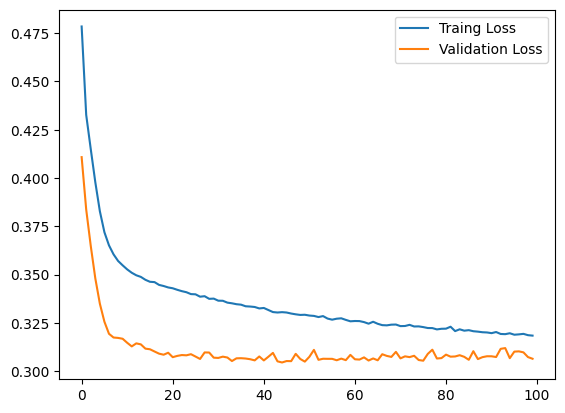

In [20]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label="Traing Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.legend()
plt.show()

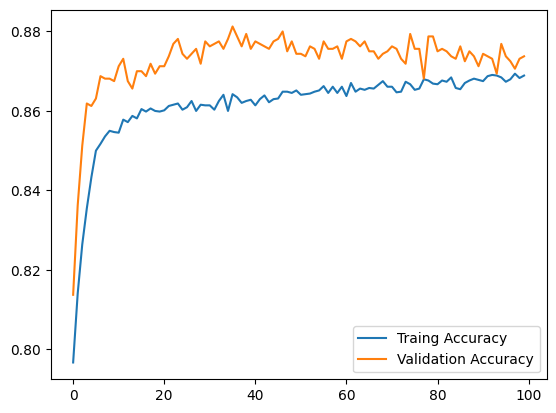

In [21]:
plt.plot(history.history['Accuracy'], label="Traing Accuracy")
plt.plot(history.history['val_Accuracy'], label="Validation Accuracy")

plt.legend()
plt.show()